In [47]:
print(output_path.exists())

True


In [48]:
processed_dir = BASE_DIR / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "ma_municipalities_clean.geojson"

towns_muni.to_file(output_path, driver="GeoJSON")

print("Saved to:", output_path)

Saved to: c:\Users\waish\OneDrive\Desktop\recovery-access-gap-index\data\processed\ma_municipalities_clean.geojson


<Axes: >

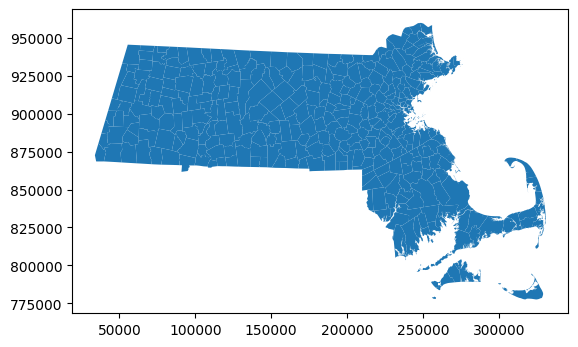

In [49]:
towns_muni.plot()

In [50]:
towns_muni = towns_poly.dissolve(
    by=["TOWN", "TOWN_ID", "COUNTY"],
    as_index=False
)

print("Rows after dissolve:", len(towns_muni))
print("Columns:")
print(towns_muni.columns)

towns_muni[["TOWN", "TOWN_ID", "COUNTY", "AREA_SQMI"]].head()

Rows after dissolve: 351
Columns:
Index(['TOWN', 'TOWN_ID', 'COUNTY', 'geometry', 'TYPE', 'FIPS_STCO',
       'FOURCOLOR', 'AREA_ACRES', 'AREA_SQMI', 'ISLAND', 'COASTAL_PO',
       'SHAPE_Leng', 'SHAPE_Area'],
      dtype='str')


,TOWN,TOWN_ID,COUNTY,AREA_SQMI
0,ABINGTON,1,PLYMOUTH,10.190
1,ACTON,2,MIDDLESEX,20.295
2,ACUSHNET,3,BRISTOL,18.878
3,ADAMS,4,BERKSHIRE,22.960
4,AGAWAM,5,HAMPDEN,24.335


In [51]:
print("Total polygon rows:", len(towns_poly))
print("Unique towns:", towns_poly["TOWN"].nunique())
print("Unique town IDs:", towns_poly["TOWN_ID"].nunique())

towns_poly[["TOWN", "TOWN_ID", "TYPE", "COUNTY", "AREA_SQMI", "ISLAND"]].head(20)

Total polygon rows: 1239
Unique towns: 351
Unique town IDs: 351


,TOWN,TOWN_ID,TYPE,COUNTY,AREA_SQMI,ISLAND
0,EASTHAM,86,T,BARNSTABLE,0.003,1
1,EASTHAM,86,T,BARNSTABLE,0.001,1
2,EASTHAM,86,T,BARNSTABLE,0.011,1
3,DUXBURY,82,T,PLYMOUTH,0.000,0
4,EAST BRIDGEWATER,83,T,PLYMOUTH,15.508,0
5,TRURO,300,T,BARNSTABLE,22.003,0
6,EAST LONGMEADOW,85,T,HAMPDEN,13.007,0
7,WHITMAN,338,T,PLYMOUTH,6.958,0
8,MARSHFIELD,171,T,PLYMOUTH,0.001,1
9,PEMBROKE,231,T,PLYMOUTH,0.080,0


In [52]:
poly_path = massgis_dir / "TOWNSSURVEY_POLY.shp"

towns_poly = gpd.read_file(poly_path)

print("Rows:", len(towns_poly))
print("Columns:")
print(towns_poly.columns)

towns_poly.head()

Rows: 1239
Columns:
Index(['TOWN', 'TOWN_ID', 'TYPE', 'COUNTY', 'FIPS_STCO', 'FOURCOLOR',
       'AREA_ACRES', 'AREA_SQMI', 'ISLAND', 'COASTAL_PO', 'SHAPE_Leng',
       'SHAPE_Area', 'geometry'],
      dtype='str')


,TOWN,TOWN_ID,TYPE,COUNTY,FIPS_STCO,FOURCOLOR,AREA_ACRES,AREA_SQMI,ISLAND,COASTAL_PO,SHAPE_Leng,SHAPE_Area,geometry
0,EASTHAM,86,T,BARNSTABLE,25001,4,1.807,0.003,1,NO,396.854753,7.313698e+03,"POLYGON ((329350.472 843775.885, 329339.623 84..."
1,EASTHAM,86,T,BARNSTABLE,25001,4,0.646,0.001,1,NO,227.900784,2.615242e+03,"POLYGON ((328266.873 843971.255, 328273.032 84..."
2,EASTHAM,86,T,BARNSTABLE,25001,4,7.274,0.011,1,NO,933.678991,2.943564e+04,"POLYGON ((328689.943 844204.565, 328676.532 84..."
3,DUXBURY,82,T,PLYMOUTH,25023,1,0.069,0.000,0,NO,74.590395,2.806099e+02,"POLYGON ((269758.712 869045.445, 269785.322 86..."
4,EAST BRIDGEWATER,83,T,PLYMOUTH,25023,4,9925.125,15.508,0,NO,44876.996336,4.016557e+07,"POLYGON ((248989.373 868088.295, 249711.212 86..."


In [53]:
for shp in massgis_dir.rglob("*.shp"):
    print(shp.name)

TOWNSSURVEY_ARC.shp
TOWNSSURVEY_ARC_GENCOAST.shp
TOWNSSURVEY_POLY.shp
TOWNSSURVEY_POLYM.shp
TOWNSSURVEY_POLYM_GENCOAST.shp
TOWNSSURVEY_PT.shp


In [54]:
shapefile_path = massgis_dir / "TOWNSSURVEY_ARC.shp"

towns = gpd.read_file(shapefile_path)

print("Rows:", len(towns))
print("Columns:")
print(towns.columns)

towns.head()

Rows: 2589
Columns:
Index(['BND_QUAL', 'FINISHED', 'BND_UNCLAS', 'REASON', 'OUTLINE', 'SHAPE_LEN',
       'geometry'],
      dtype='str')


,BND_QUAL,FINISHED,BND_UNCLAS,REASON,OUTLINE,SHAPE_LEN,geometry
0,0,YES,0,Not Applicable,4,96093.874444,"LINESTRING (231691.892 805288.875, 231705.972 ..."
1,3,YES,0,Not Applicable,17,6521.885605,"LINESTRING (78407.362 905597.525, 78433.072 90..."
2,0,YES,0,Not Applicable,4,7819.817909,"LINESTRING (268729.653 807412.375, 268738.222 ..."
3,0,YES,0,Not Applicable,4,28463.431498,"LINESTRING (275207.932 798121.125, 275191.233 ..."
4,0,YES,0,Not Applicable,4,3707.815622,"LINESTRING (271059.432 788903.745, 271193.062 ..."


In [55]:
import geopandas as gpd
from pathlib import Path

massgis_dir = DATA_RAW / "massgis_municipalities"

print("Files in MassGIS folder:")
for file in massgis_dir.iterdir():
    print(file.name)

Files in MassGIS folder:
MA_Towns_Survey_Bnd_Qual.lyr
MA_Towns_Survey_Dashed_Outlines.lyr
MA_Towns_Survey_Multi_Shaded.lyr
MA_Towns_Survey_Points.lyr
MA_Towns_Survey_Shaded.lyr
MA_Towns_Survey_Shaded_Group.lyr
TOWNSSURVEY_ARC.cpg
TOWNSSURVEY_ARC.dbf
TOWNSSURVEY_ARC.prj
TOWNSSURVEY_ARC.sbn
TOWNSSURVEY_ARC.sbx
TOWNSSURVEY_ARC.shp
TOWNSSURVEY_ARC.shp.xml
TOWNSSURVEY_ARC.shx
TOWNSSURVEY_ARC_GENCOAST.cpg
TOWNSSURVEY_ARC_GENCOAST.dbf
TOWNSSURVEY_ARC_GENCOAST.prj
TOWNSSURVEY_ARC_GENCOAST.sbn
TOWNSSURVEY_ARC_GENCOAST.sbx
TOWNSSURVEY_ARC_GENCOAST.shp
TOWNSSURVEY_ARC_GENCOAST.shp.xml
TOWNSSURVEY_ARC_GENCOAST.shx
TOWNSSURVEY_POLY.cpg
TOWNSSURVEY_POLY.dbf
TOWNSSURVEY_POLY.prj
TOWNSSURVEY_POLY.sbn
TOWNSSURVEY_POLY.sbx
TOWNSSURVEY_POLY.shp
TOWNSSURVEY_POLY.shp.xml
TOWNSSURVEY_POLY.shx
TOWNSSURVEY_POLYM.cpg
TOWNSSURVEY_POLYM.dbf
TOWNSSURVEY_POLYM.prj
TOWNSSURVEY_POLYM.sbn
TOWNSSURVEY_POLYM.sbx
TOWNSSURVEY_POLYM.shp
TOWNSSURVEY_POLYM.shp.xml
TOWNSSURVEY_POLYM.shx
TOWNSSURVEY_POLYM_GENCOAST.cpg
TOWNSSU

In [56]:
from pathlib import Path

# Notebook is inside /notebooks, so parent folder is the project root
BASE_DIR = Path.cwd().parent
DATA_RAW = BASE_DIR / "data" / "raw"

print("Base directory:", BASE_DIR)
print("Raw data directory exists:", DATA_RAW.exists())

for folder in DATA_RAW.iterdir():
    print(folder.name)

Base directory: c:\Users\waish\OneDrive\Desktop\recovery-access-gap-index
Raw data directory exists: True
ems_incidents
massgis_municipalities
overdose_deaths
samhsa_treatment
svi
